In [34]:
from google.colab import files


(np.float64(-0.5), np.float64(974.5), np.float64(552.5), np.float64(-0.5))

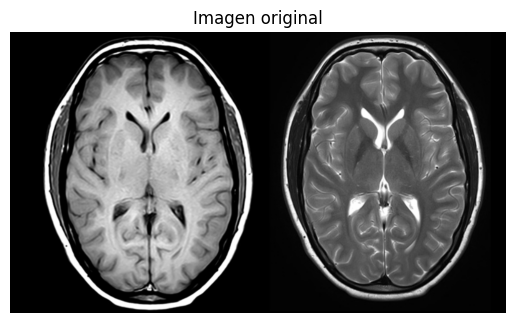

In [35]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('imagen.jpeg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Imagen original")
plt.axis('off')

(np.float64(-0.5), np.float64(974.5), np.float64(552.5), np.float64(-0.5))

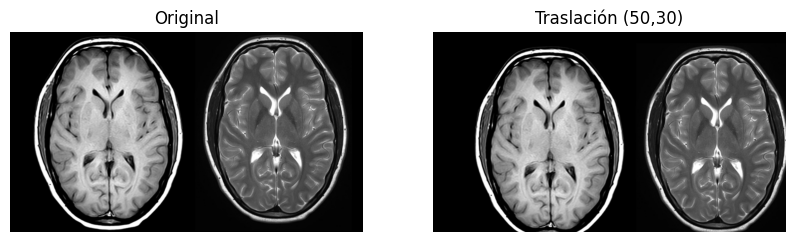

In [36]:
import numpy as np

# Obtener dimensiones
filas, columnas = img.shape[:2]

# Crear matriz de traslación (mover 50 px derecha, 30 px abajo)
M = np.float32([[1, 0, 50],
                [0, 1, 30]])

# Aplicar traslación
img_trasladada = cv2.warpAffine(img, M, (columnas, filas))

# Mostrar ambas imágenes
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(img_trasladada, cv2.COLOR_BGR2RGB))
plt.title("Traslación (50,30)")
plt.axis('off')

(np.float64(-0.5), np.float64(974.5), np.float64(552.5), np.float64(-0.5))

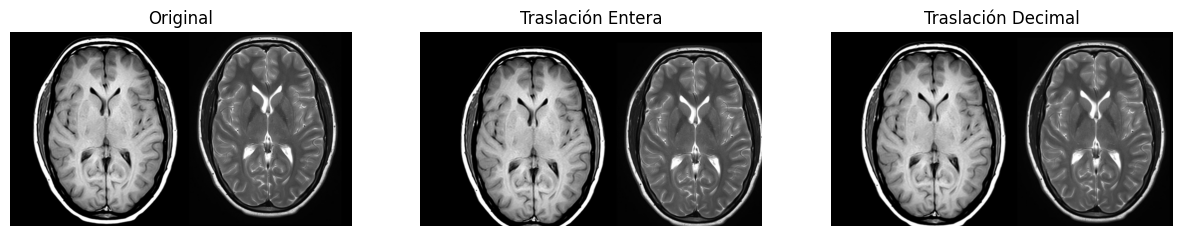

In [37]:
# Traslación con decimales
M_decimal = np.float32([[1, 0, 20.5],
                        [0, 1, 15.5]])

img_decimal = cv2.warpAffine(img, M_decimal, (columnas, filas))

# Mostrar comparación
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(img_trasladada, cv2.COLOR_BGR2RGB))
plt.title("Traslación Entera")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(img_decimal, cv2.COLOR_BGR2RGB))
plt.title("Traslación Decimal")
plt.axis('off')

(np.float64(-0.5), np.float64(974.5), np.float64(552.5), np.float64(-0.5))

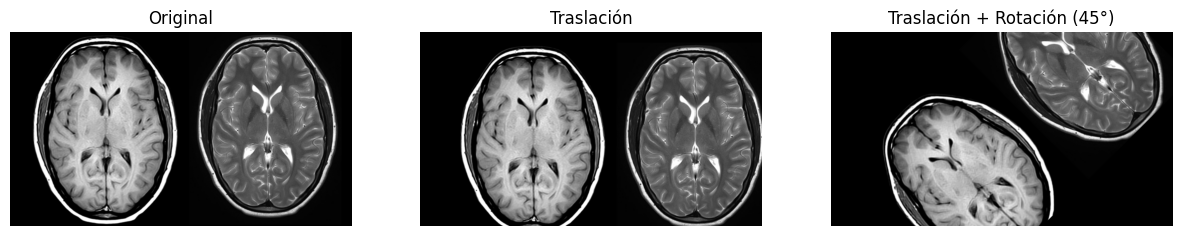

In [38]:
# Centro de la imagen
centro = (columnas // 2, filas // 2)

# Rotación de 45 grados
M_rot = cv2.getRotationMatrix2D(centro, 45, 1)

# Aplicar rotación a la imagen ya trasladada
img_rotada = cv2.warpAffine(img_trasladada, M_rot, (columnas, filas))

# Mostrar resultados
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(img_trasladada, cv2.COLOR_BGR2RGB))
plt.title("Traslación")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(img_rotada, cv2.COLOR_BGR2RGB))
plt.title("Traslación + Rotación (45°)")
plt.axis('off')

(np.float64(-0.5), np.float64(974.5), np.float64(552.5), np.float64(-0.5))

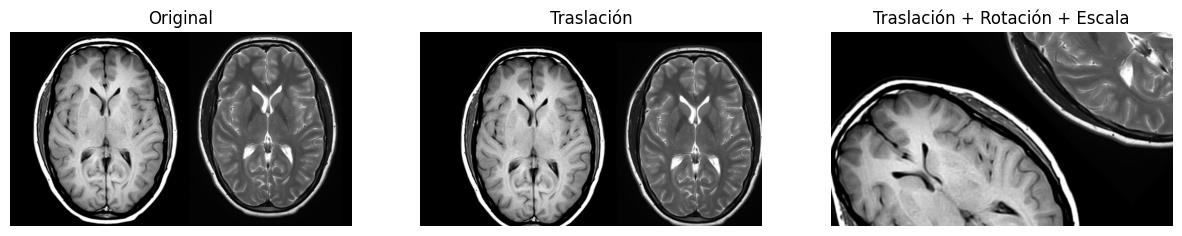

In [39]:
# Escala (1.5 para agrandar, o 0.5 para hacerla más chica)
escala = 1.5

# Rotación + escala al mismo tiempo
M_rot_esc = cv2.getRotationMatrix2D(centro, 45, escala)

# Aplicar a la imagen trasladada
img_rot_esc = cv2.warpAffine(img_trasladada, M_rot_esc, (columnas, filas))

# Mostrar resultados
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(img_trasladada, cv2.COLOR_BGR2RGB))
plt.title("Traslación")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(img_rot_esc, cv2.COLOR_BGR2RGB))
plt.title("Traslación + Rotación + Escala")
plt.axis('off')

(np.float64(-0.5), np.float64(974.5), np.float64(552.5), np.float64(-0.5))

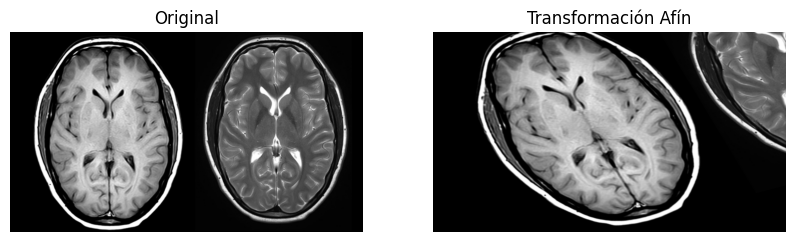

In [40]:
# Puntos originales (de la imagen)
pts1 = np.float32([[50,50], [200,50], [50,200]])

# Nuevos puntos (cómo quieres deformarla)
pts2 = np.float32([[10,100], [200,50], [100,250]])

# Matriz afín
M_afin = cv2.getAffineTransform(pts1, pts2)

# Aplicar transformación
img_afin = cv2.warpAffine(img, M_afin, (columnas, filas))

# Mostrar
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(img_afin, cv2.COLOR_BGR2RGB))
plt.title("Transformación Afín")
plt.axis('off')

(np.float64(-0.5), np.float64(974.5), np.float64(552.5), np.float64(-0.5))

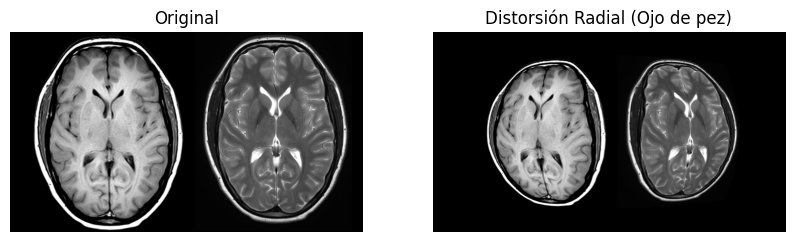

In [41]:
# Crear mapas
map_x = np.zeros((filas, columnas), np.float32)
map_y = np.zeros((filas, columnas), np.float32)

cx, cy = columnas / 2, filas / 2

for i in range(filas):
    for j in range(columnas):
        x = (j - cx) / cx
        y = (i - cy) / cy
        r = np.sqrt(x**2 + y**2)

        factor = 1 + 0.5 * (r**2)

        map_x[i,j] = cx + x * factor * cx
        map_y[i,j] = cy + y * factor * cy

# Aplicar distorsión
img_radial = cv2.remap(img, map_x, map_y, cv2.INTER_LINEAR)

# Mostrar
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(img_radial, cv2.COLOR_BGR2RGB))
plt.title("Distorsión Radial (Ojo de pez)")
plt.axis('off')